# 32 — Wu 2003 CNN Embedding Study

**Purpose:** Test whether a CNN embedding that learns summary statistics directly
from raw S-B time series resolves the three representation artifacts identified in
notebooks 29b/30/31:

1. **(alpha, eta_col) banana at W12** — restricted-channel artifact
2. **(alpha, beta_r) banana at W11** — lossy-temporal-aggregation artifact
3. **(alpha/beta_r, z_A0_eff) at W10** — same mechanism; feed-fault F1 = 0.00

The FIM analysis (nb29b) showed all three collapse when using raw trajectories
instead of the 66-D `compute_summaries`. This notebook is the decisive confirmation:
retrain SBI with a CNN that sees the raw `(120, 9)` S-B observation, then evaluate
posteriors, classification, and 30-day tracking.

---
## §1 — Setup and configuration

In [1]:
from __future__ import annotations

import pathlib
import pickle
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import jax.numpy as jnp
from scipy import stats as scipy_stats

sys.path.insert(0, str(pathlib.Path.cwd().parent / 'scripts'))
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

from sbi_pipeline import (
    generate_raw_training_bank,
    train_cnn_posterior,
    run_sbc_cnn,
    train_cnn_ensemble_and_select,
    _simulate_raw_sb,
    _structure_config,
    PARAM_NAMES,
)
from cstr_sbi.recycle.priors import box_uniform_5d
from cstr_sbi.recycle.physics import (
    NOMINAL_CTRL_SB, NOMINAL_INLET,
    simulate_trajectory_explicit, extract_observations_explicit,
)
from cstr_sbi.recycle.summaries import (
    compute_summaries, SB_INDICES, SB_CHANNELS, N_SUMMARIES_SB,
)
from cstr_sbi.recycle.simulator import nominal_warm_start
from cstr_sbi.recycle.scenarios import list_configs, CLOSED_LOOP_NAMES

ROOT     = pathlib.Path.cwd().parent
DATA     = ROOT / 'data'
SBI_LOGS = ROOT / 'sbi-logs'
FIGURES  = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

OI = plt.cm.tab10.colors
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

print(f'torch {torch.__version__}, CUDA={torch.cuda.is_available()}')
print(f'Working dir: {ROOT}')

torch 2.12.0, CUDA=False
Working dir: /Users/simo/inso-po-RD/cstr-model-optimisation/research_project


In [2]:
# CNN experiment configuration
N_TRAIN       = 15_000
N_SEEDS       = 8
N_SBC         = 400
N_POST_SBC    = 200
N_POST_EVAL   = 500
NOISE_PCT     = 0.003
STRUCTURE     = 'S-B'
BANK_SEED     = 20260625

# CNN architecture
CNN_OUTPUT_DIM    = 30
NSF_HIDDEN        = 60
NSF_TRANSFORMS    = 3

# Paths
BANK_PATH     = DATA / 'wu2003_sbi_train_sb_cnn.npz'
PROD_PKL      = SBI_LOGS / 'wu2003_posterior_sb.pkl'
CNN_PKL       = SBI_LOGS / 'wu2003_posterior_sb_cnn.pkl'
OBS_PATH      = DATA / 'wu2003_observations.npz'

# Fault classification thresholds (matching nb31)
FAULT_THRESH  = 0.85
Z0_NOM        = 0.90
FAULT_UNITS   = ['healthy', 'reactor', 'column', 'feed', 'multi']


def sample_direct(posterior, x, n):
    """Sample the underlying flow directly, bypassing DirectPosterior.sample()'s
    prior-support rejection loop. sbi 0.26's DirectPosterior.sample() defaults to
    reject_outside_prior=True and can spin near-indefinitely if the flow's mass for a
    given observation drifts outside the training prior box (documented hang mode in
    this project -- see nb27/nb31 sample_posterior_direct)."""
    with torch.no_grad():
        samp = posterior.posterior_estimator.sample(
            (n,), condition=x.reshape(1, -1),
        )
    return samp.reshape(-1, 5).numpy()


print('Configuration set.')

Configuration set.


---
## §2 — Generate raw training bank

In [3]:
generate_raw_training_bank(
    STRUCTURE, NOISE_PCT, BANK_PATH,
    n_train=N_TRAIN, seed=BANK_SEED,
)

# Verify
bank = np.load(BANK_PATH)
print(f"\nthetas:  {bank['thetas'].shape}, dtype={bank['thetas'].dtype}")
print(f"raw_obs: {bank['raw_obs'].shape}, dtype={bank['raw_obs'].dtype}")
assert bank['raw_obs'].shape[1:] == (120, 9), f"Unexpected shape: {bank['raw_obs'].shape}"
assert not np.isnan(bank['raw_obs']).any(), 'NaN in raw_obs'
assert not np.isinf(bank['raw_obs']).any(), 'Inf in raw_obs'
print('Bank verified: no NaN/Inf, correct shape.')

[bank-cnn] /Users/simo/inso-po-RD/cstr-model-optimisation/research_project/data/wu2003_sbi_train_sb_cnn.npz already exists, reusing

thetas:  (15000, 5), dtype=float32
raw_obs: (15000, 120, 9), dtype=float32
Bank verified: no NaN/Inf, correct shape.


---
## §3 — Train 8-seed CNN ensemble + §4 — SBC calibration (N=400)

In [4]:
if CNN_PKL.exists():
    print(f'{CNN_PKL} already exists, loading from disk (skipping ensemble retraining)')
    with open(CNN_PKL, 'rb') as f:
        _cnn_data = pickle.load(f)
    best_posterior = _cnn_data['posterior']
    best_seed = _cnn_data['selected_seed']
    per_seed_results = _cnn_data['all_seeds']
    print(f"Loaded seed {best_seed}, selection: {_cnn_data.get('selection_method')}")
else:
    best_posterior, best_seed, per_seed_results = train_cnn_ensemble_and_select(
        bank_path=BANK_PATH,
        structure=STRUCTURE,
        noise_pct=NOISE_PCT,
        hidden_features=NSF_HIDDEN,
        num_transforms=NSF_TRANSFORMS,
        output_dim=CNN_OUTPUT_DIM,
        seeds=list(range(N_SEEDS)),
        n_sbc=N_SBC,
        n_post=N_POST_SBC,
    )

/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/sbi-logs/wu2003_posterior_sb_cnn.pkl already exists, loading from disk (skipping ensemble retraining)


Loaded seed 6, selection: 8 seeds, SBC N=400, max(min KS p)


In [5]:
# SBC results table
print(f"{'seed':>4}  {'min_KS_p':>9}  ", end='')
for name in PARAM_NAMES:
    print(f"{name:>10}", end='')
print()
print('-' * 70)

for r in per_seed_results:
    print(f"{r['seed']:4d}  {r['min_ks_pvalue']:9.4f}  ", end='')
    for name in PARAM_NAMES:
        p = r['sbc'][name]['ks_pvalue']
        marker = '*' if p < 0.05 else ' '
        print(f"{p:9.4f}{marker}", end='')
    print()

n_pass = sum(1 for r in per_seed_results if r['min_ks_pvalue'] > 0.05)
print(f"\n{n_pass}/{N_SEEDS} seeds pass SBC (all KS p > 0.05)")
print(f"Selected seed: {best_seed}")

seed   min_KS_p       alpha    beta_r   eta_col    xi_reb  z_A0_eff
----------------------------------------------------------------------
   0     0.0002     0.5309    0.5309    0.0211*   0.2612    0.0002*
   1     0.0000     0.6135    0.5309    0.4529    0.0000*   0.0029*
   2     0.0014     0.0211*   0.0211*   0.0014*   0.0155*   0.6977 
   3     0.0001     0.4529    0.3174    0.0058*   0.0001*   0.3174 
   4     0.0000     0.1078    0.1078    0.0000*   0.0081*   0.2126 
   5     0.0029     0.1366    0.0081*   0.0041*   0.0029*   0.0081*
   6     0.1366     0.6135    0.3174    0.2612    0.6135    0.1366 
   7     0.0378     0.0378*   0.0651    0.0651    0.2612    0.6135 

1/8 seeds pass SBC (all KS p > 0.05)
Selected seed: 6


In [6]:
# Save selected CNN posterior (skip if already loaded from disk in §3)
best_meta = next(r for r in per_seed_results if r['seed'] == best_seed)
if not CNN_PKL.exists():
    with open(CNN_PKL, 'wb') as f:
        pickle.dump({
            'posterior': best_posterior,
            'selected_seed': best_seed,
            'N_TRAIN': N_TRAIN,
            'arch': 'zuko_nsf',
            'hidden_features': NSF_HIDDEN,
            'num_transforms': NSF_TRANSFORMS,
            'cnn_output_dim': CNN_OUTPUT_DIM,
            'sbc': best_meta['sbc'],
            'training_meta': best_meta['meta'],
            'selection_method': f'{N_SEEDS} seeds, SBC N={N_SBC}, max(min KS p)',
            'all_seeds': per_seed_results,
        }, f)
    print(f'Saved CNN posterior to {CNN_PKL}')
else:
    print(f'{CNN_PKL} already on disk, not overwriting.')
print(f'CNN params: {best_meta["meta"]["n_cnn_params"]:,}')
print(f'Training wall time: {best_meta["meta"]["wall_time_s"]:.0f}s')

/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/sbi-logs/wu2003_posterior_sb_cnn.pkl already on disk, not overwriting.
CNN params: 62,686
Training wall time: 239s


---
## §5 — Posterior evaluation at artifact scenarios

In [7]:
# Load CNN posterior (from §4 or from disk if restarting)
if 'best_posterior' not in dir():
    with open(CNN_PKL, 'rb') as f:
        _cnn_data = pickle.load(f)
    best_posterior = _cnn_data['posterior']
    best_seed = _cnn_data['selected_seed']
    print(f'Loaded CNN posterior (seed {best_seed}) from disk')

# Load production hand-crafted posterior
with open(PROD_PKL, 'rb') as f:
    _prod_data = pickle.load(f)
prod_posterior = _prod_data['posterior']
print(f"Production posterior: seed={_prod_data.get('selected_seed')}, "
      f"N_TRAIN={_prod_data.get('N_TRAIN')}")

# Load observations
obs_data = np.load(OBS_PATH, allow_pickle=True)
obs_sb = obs_data['observations_sb']  # (420, 120, 9)
labels = obs_data['labels']           # structured array
t_h = obs_data['t_h']
print(f"Observations: {obs_sb.shape} (14 scenarios x 30 replicates)")

# Load pre-computed 66-D summary FEATURES for the hand-crafted posterior.
# wu2003_summary_features.npz stores pre-*compression* features (raw physical
# units, e.g. Q_j ~ 1e7) -- compute_summaries() applies a signed-log1p compression
# (_compress_heavy_tails) before returning, and the production posterior was
# trained on the *compressed* vectors. Feeding the raw X_sb directly puts every
# observation far outside the training distribution (100% of posterior samples
# fall outside the prior box) and gives nonsense fault estimates. Apply the same
# compression here to match what the posterior actually expects.
from cstr_sbi.recycle.summaries import _compress_heavy_tails
feat_data = np.load(DATA / 'wu2003_summary_features.npz', allow_pickle=True)
summaries_sb = _compress_heavy_tails(feat_data['X_sb'])  # (420, 66)
print(f"Hand-crafted summaries: {summaries_sb.shape} (heavy-tail compressed)")

Production posterior: seed=4, N_TRAIN=15000
Observations: (420, 120, 9) (14 scenarios x 30 replicates)
Hand-crafted summaries: (420, 66) (heavy-tail compressed)


In [8]:
# Draw posterior samples from both methods for all 420 windows
n_windows = obs_sb.shape[0]

print(f"Drawing {N_POST_EVAL} posterior samples x {n_windows} windows...")
t0 = time.time()

cnn_samples = np.zeros((n_windows, N_POST_EVAL, 5))
hc_samples  = np.zeros((n_windows, N_POST_EVAL, 5))

for i in range(n_windows):
    # CNN: raw (120,9) -> flat (1, 1080)
    obs_flat = torch.tensor(
        obs_sb[i].reshape(1, -1), dtype=torch.float32
    )
    cnn_samples[i] = sample_direct(best_posterior, obs_flat, N_POST_EVAL)

    # Hand-crafted: 66-D summary
    s = torch.tensor(
        summaries_sb[i].reshape(1, -1), dtype=torch.float32
    )
    hc_samples[i] = sample_direct(prod_posterior, s, N_POST_EVAL)

    if (i + 1) % 60 == 0:
        print(f"  {i+1}/{n_windows}  ({time.time()-t0:.0f}s)")

print(f"Done in {time.time()-t0:.0f}s")
print(f"CNN samples: {cnn_samples.shape}")
print(f"HC  samples: {hc_samples.shape}")

Drawing 500 posterior samples x 420 windows...


  60/420  (2s)


  120/420  (4s)


  180/420  (6s)


  240/420  (8s)


  300/420  (10s)


  360/420  (12s)


  420/420  (14s)
Done in 14s
CNN samples: (420, 500, 5)
HC  samples: (420, 500, 5)


In [9]:
# Build scenario lookup
scenario_names = np.array([str(l) for l in labels['scenario_name']])
unique_scenarios = []
for name in dict.fromkeys(scenario_names):
    unique_scenarios.append(name)

N_REPS = 30
scenario_slices = {}
for i, name in enumerate(unique_scenarios):
    start = i * N_REPS
    scenario_slices[name] = slice(start, start + N_REPS)

# Ground truth per scenario (from labels)
scenario_truth = {}
for name, sl in scenario_slices.items():
    scenario_truth[name] = {
        p: float(labels[p][sl.start]) for p in PARAM_NAMES
    }

# Ground truth fault unit from scenarios module (matches nb31)
from cstr_sbi.recycle.scenarios import get_scenario
scenario_true_unit = {}
for name in unique_scenarios:
    cfg = get_scenario(name)
    scenario_true_unit[name] = cfg.fault_unit()

print(f"{len(unique_scenarios)} scenarios:")
for name in unique_scenarios:
    truth = scenario_truth[name]
    unit = scenario_true_unit[name]
    npz_unit = str(labels['fault_unit'][scenario_slices[name].start])
    mismatch = ' **MISMATCH**' if unit != npz_unit else ''
    print(f"  {name:25s} unit={unit:10s} "
          f"alpha={truth['alpha']:.2f} beta_r={truth['beta_r']:.2f} "
          f"eta_col={truth['eta_col']:.2f} z_A0={truth['z_A0_eff']:.2f}{mismatch}")

14 scenarios:
  W1_healthy                unit=healthy    alpha=1.00 beta_r=1.00 eta_col=1.00 z_A0=0.90
  W2_cat_mild               unit=reactor    alpha=0.85 beta_r=1.00 eta_col=1.00 z_A0=0.90
  W3_cat_severe             unit=reactor    alpha=0.65 beta_r=1.00 eta_col=1.00 z_A0=0.90
  W4_cat_threshold          unit=reactor    alpha=0.55 beta_r=1.00 eta_col=1.00 z_A0=0.90
  W5_jacket_mild            unit=reactor    alpha=1.00 beta_r=0.80 eta_col=1.00 z_A0=0.90
  W6_jacket_severe          unit=reactor    alpha=1.00 beta_r=0.60 eta_col=1.00 z_A0=0.90
  W7_col_eff_mild           unit=column     alpha=1.00 beta_r=1.00 eta_col=0.80 z_A0=0.90
  W9_reb_fouling            unit=column     alpha=1.00 beta_r=1.00 eta_col=1.00 z_A0=0.90
  W10_feed_impurity         unit=feed       alpha=1.00 beta_r=1.00 eta_col=1.00 z_A0=0.78
  W11_reactor_combined      unit=reactor    alpha=0.80 beta_r=0.80 eta_col=1.00 z_A0=0.90
  W12_snowball_compound     unit=multi      alpha=0.75 beta_r=1.00 eta_col=0.80 z_A0=0

In [10]:
# Artifact scenario analysis
ARTIFACT_SCENARIOS = {
    'W11_reactor_combined': {
        'issue': '(alpha, beta_r) banana',
        'params': ('alpha', 'beta_r'),
        'pidx': (0, 1),
    },
    'W12_snowball_compound': {
        'issue': '(alpha, eta_col) banana',
        'params': ('alpha', 'eta_col'),
        'pidx': (0, 2),
    },
    'W10_feed_impurity': {
        'issue': '(alpha/beta_r, z_A0_eff) degeneracy',
        'params': ('alpha', 'z_A0_eff'),
        'pidx': (0, 4),
    },
    'W13_cat_feed': {
        'issue': 'alpha + z_A0_eff separability',
        'params': ('alpha', 'z_A0_eff'),
        'pidx': (0, 4),
    },
}

# Compute per-scenario posterior statistics
print(f"{'Scenario':<25} {'Param':<10} {'Truth':>6} "
      f"{'HC_mean':>8} {'HC_bias':>8} {'CNN_mean':>9} {'CNN_bias':>9} "
      f"{'HC_corr':>8} {'CNN_corr':>9}")
print('-' * 110)

for sc_name, info in ARTIFACT_SCENARIOS.items():
    sl = scenario_slices[sc_name]
    truth = scenario_truth[sc_name]
    p1, p2 = info['params']
    i1, i2 = info['pidx']

    # Pool all replicates
    cnn_pooled = cnn_samples[sl].reshape(-1, 5)
    hc_pooled  = hc_samples[sl].reshape(-1, 5)

    # Correlation between the two parameters
    hc_corr  = np.corrcoef(hc_pooled[:, i1], hc_pooled[:, i2])[0, 1]
    cnn_corr = np.corrcoef(cnn_pooled[:, i1], cnn_pooled[:, i2])[0, 1]

    for param, pidx in [(p1, i1), (p2, i2)]:
        t = truth[param]
        hc_m  = hc_pooled[:, pidx].mean()
        cnn_m = cnn_pooled[:, pidx].mean()
        corr_str = f"{hc_corr:+.3f}" if param == p1 else ''
        cnn_corr_str = f"{cnn_corr:+.3f}" if param == p1 else ''
        print(f"{sc_name:<25} {param:<10} {t:6.3f} "
              f"{hc_m:8.3f} {hc_m-t:+8.3f} {cnn_m:9.3f} {cnn_m-t:+9.3f} "
              f"{corr_str:>8} {cnn_corr_str:>9}")
    print()

Scenario                  Param       Truth  HC_mean  HC_bias  CNN_mean  CNN_bias  HC_corr  CNN_corr
--------------------------------------------------------------------------------------------------------------
W11_reactor_combined      alpha       0.800    0.705   -0.095     0.810    +0.010   +0.994    +0.993
W11_reactor_combined      beta_r      0.800    0.657   -0.143     0.802    +0.002                   

W12_snowball_compound     alpha       0.750    0.635   -0.115     0.708    -0.042   +0.011    +0.010
W12_snowball_compound     eta_col     0.800    0.804   +0.004     0.741    -0.059                   

W10_feed_impurity         alpha       1.000    1.021   +0.021     0.828    -0.172   +0.995    -0.004
W10_feed_impurity         z_A0_eff    0.780    0.798   +0.018     0.830    +0.050                   

W13_cat_feed              alpha       0.800    0.776   -0.024     0.694    -0.106   +0.993    -0.003
W13_cat_feed              z_A0_eff    0.800    0.777   -0.023     0.830    +0.

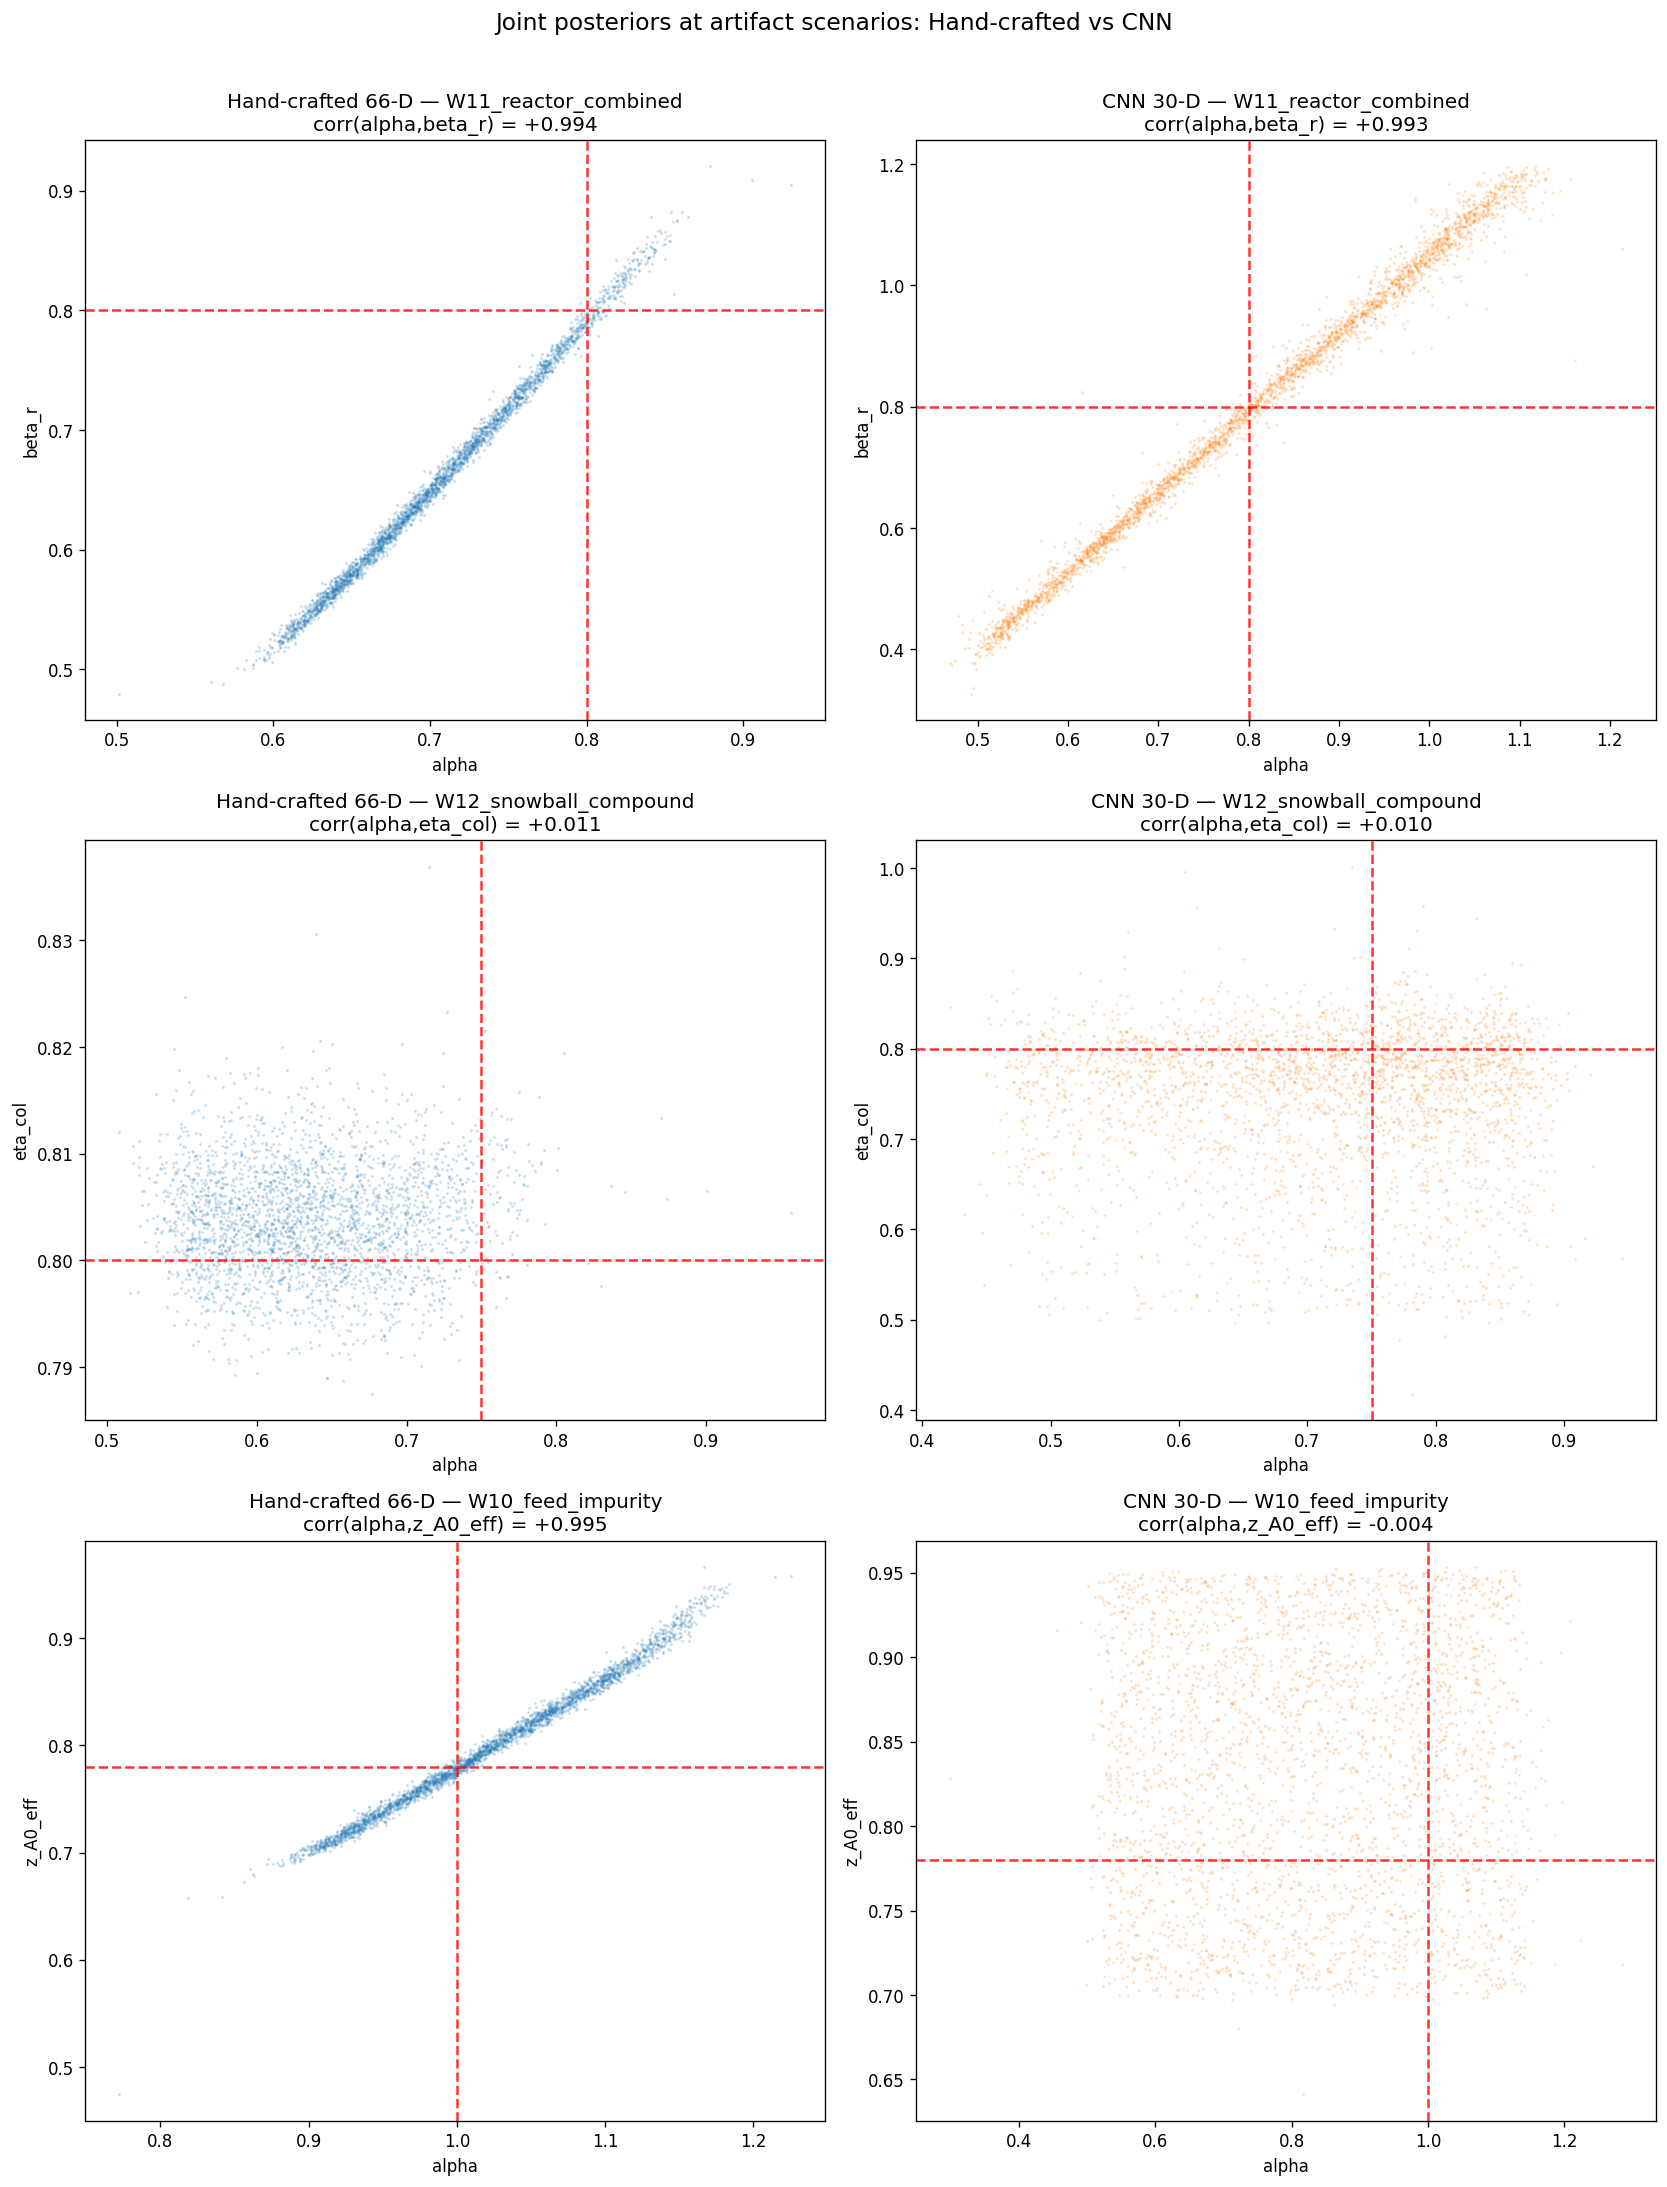

Saved 32_cnn_artifact_joints.png


In [11]:
# Joint posterior plots for artifact scenarios
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

artifact_list = [
    ('W11_reactor_combined', 0, 1, 'alpha', 'beta_r'),
    ('W12_snowball_compound', 0, 2, 'alpha', 'eta_col'),
    ('W10_feed_impurity', 0, 4, 'alpha', 'z_A0_eff'),
]

for row, (sc_name, i1, i2, p1, p2) in enumerate(artifact_list):
    sl = scenario_slices[sc_name]
    truth = scenario_truth[sc_name]
    cnn_pooled = cnn_samples[sl].reshape(-1, 5)
    hc_pooled  = hc_samples[sl].reshape(-1, 5)

    # Hand-crafted
    ax = axes[row, 0]
    ax.scatter(hc_pooled[::5, i1], hc_pooled[::5, i2],
               s=1, alpha=0.15, color=OI[0])
    ax.axvline(truth[p1], color='red', ls='--', lw=1.5, alpha=0.8)
    ax.axhline(truth[p2], color='red', ls='--', lw=1.5, alpha=0.8)
    corr = np.corrcoef(hc_pooled[:, i1], hc_pooled[:, i2])[0, 1]
    ax.set_title(f'Hand-crafted 66-D — {sc_name}\ncorr({p1},{p2}) = {corr:+.3f}')
    ax.set_xlabel(p1); ax.set_ylabel(p2)

    # CNN
    ax = axes[row, 1]
    ax.scatter(cnn_pooled[::5, i1], cnn_pooled[::5, i2],
               s=1, alpha=0.15, color=OI[1])
    ax.axvline(truth[p1], color='red', ls='--', lw=1.5, alpha=0.8)
    ax.axhline(truth[p2], color='red', ls='--', lw=1.5, alpha=0.8)
    corr = np.corrcoef(cnn_pooled[:, i1], cnn_pooled[:, i2])[0, 1]
    ax.set_title(f'CNN 30-D — {sc_name}\ncorr({p1},{p2}) = {corr:+.3f}')
    ax.set_xlabel(p1); ax.set_ylabel(p2)

plt.suptitle('Joint posteriors at artifact scenarios: Hand-crafted vs CNN',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '32_cnn_artifact_joints.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 32_cnn_artifact_joints.png')

In [12]:
# Full per-scenario posterior mean comparison
print(f"{'Scenario':<25}", end='')
for p in PARAM_NAMES:
    print(f"  {p+'_hc':>11} {p+'_cnn':>11} {'truth':>7}", end='')
print()
print('-' * 160)

for sc_name in unique_scenarios:
    sl = scenario_slices[sc_name]
    truth = scenario_truth[sc_name]
    cnn_pooled = cnn_samples[sl].reshape(-1, 5)
    hc_pooled  = hc_samples[sl].reshape(-1, 5)

    print(f"{sc_name:<25}", end='')
    for k, p in enumerate(PARAM_NAMES):
        print(f"  {hc_pooled[:,k].mean():11.3f} {cnn_pooled[:,k].mean():11.3f} {truth[p]:7.3f}", end='')
    print()

Scenario                      alpha_hc   alpha_cnn   truth    beta_r_hc  beta_r_cnn   truth   eta_col_hc eta_col_cnn   truth    xi_reb_hc  xi_reb_cnn   truth  z_A0_eff_hc z_A0_eff_cnn   truth
----------------------------------------------------------------------------------------------------------------------------------------------------------------
W1_healthy                       0.962       0.829   1.000        0.955       0.784   1.000        1.001       0.967   1.000        1.015       1.007   1.000        0.866       0.831   0.900
W2_cat_mild                      0.726       0.739   0.850        0.785       0.821   1.000        1.002       0.959   1.000        1.046       1.004   1.000        0.786       0.830   0.900
W3_cat_severe                    0.561       0.596   0.650        0.763       0.873   1.000        1.003       0.949   1.000        1.088       1.016   1.000        0.811       0.829   0.900
W4_cat_threshold                 0.484       0.516   0.550        0.761   

---
## §6 — Fault classification

In [13]:
def sample_fault_unit(theta_row, thresh=FAULT_THRESH, z0_nom=Z0_NOM):
    """Classify a single posterior sample into a fault unit."""
    alpha, beta_r, eta_col, xi_reb, z_A0 = theta_row
    reactor_bad = (alpha < thresh) or (beta_r < thresh)
    column_bad  = (eta_col < thresh) or (xi_reb < thresh)
    feed_bad    = z_A0 < thresh * z0_nom
    n_bad = int(reactor_bad) + int(column_bad) + int(feed_bad)
    if n_bad == 0:   return 'healthy'
    if n_bad >= 2:   return 'multi'
    if reactor_bad:  return 'reactor'
    if column_bad:   return 'column'
    return 'feed'


def classify_window(samples):
    """Classify a window given (N_POST, 5) posterior samples."""
    labels_per_sample = [sample_fault_unit(s) for s in samples]
    counts = {u: 0 for u in FAULT_UNITS}
    for lab in labels_per_sample:
        counts[lab] += 1
    predicted = max(counts, key=counts.get)
    confidence = counts[predicted] / len(labels_per_sample)
    return predicted, confidence


# Classify all windows for both methods
cnn_preds, hc_preds = [], []
true_units = []

for i in range(n_windows):
    cnn_pred, _ = classify_window(cnn_samples[i])
    hc_pred, _  = classify_window(hc_samples[i])
    cnn_preds.append(cnn_pred)
    hc_preds.append(hc_pred)
    # Use scenario module's fault_unit (matches nb31)
    sc_name = str(labels['scenario_name'][i])
    true_units.append(scenario_true_unit[sc_name])

print(f'Classified {n_windows} windows.')

Classified 420 windows.


In [14]:
def compute_f1_metrics(trues, preds):
    c2i = {u: i for i, u in enumerate(FAULT_UNITS)}
    cm = np.zeros((5, 5), dtype=int)
    for true, pred in zip(trues, preds):
        cm[c2i[true], c2i[pred]] += 1

    f1_per_class = {}
    for i, cls in enumerate(FAULT_UNITS):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        f1_per_class[cls] = f1

    accuracy = np.trace(cm) / cm.sum()
    macro_f1 = np.mean(list(f1_per_class.values()))
    return accuracy, macro_f1, f1_per_class, cm


hc_acc, hc_f1, hc_f1c, hc_cm = compute_f1_metrics(true_units, hc_preds)
cnn_acc, cnn_f1, cnn_f1c, cnn_cm = compute_f1_metrics(true_units, cnn_preds)

print(f"{'Metric':<20} {'Hand-crafted':>14} {'CNN':>14}")
print('-' * 50)
print(f"{'Accuracy':<20} {hc_acc:14.3f} {cnn_acc:14.3f}")
print(f"{'Macro-F1':<20} {hc_f1:14.3f} {cnn_f1:14.3f}")
print()
print(f"{'Class':<12} {'HC F1':>10} {'CNN F1':>10} {'Delta':>10}")
print('-' * 44)
for cls in FAULT_UNITS:
    delta = cnn_f1c[cls] - hc_f1c[cls]
    print(f"{cls:<12} {hc_f1c[cls]:10.3f} {cnn_f1c[cls]:10.3f} {delta:+10.3f}")

Metric                 Hand-crafted            CNN
--------------------------------------------------
Accuracy                      0.869          0.619
Macro-F1                      0.679          0.270

Class             HC F1     CNN F1      Delta
--------------------------------------------
healthy           0.667      0.000     -0.667
reactor           0.967      0.800     -0.167
column            0.899      0.000     -0.899
feed              0.000      0.000     +0.000
multi             0.862      0.548     -0.314


In [15]:
# Per-scenario classification accuracy
from collections import Counter

print(f"{'Scenario':<25} {'True unit':<10} {'HC pred':<10} {'HC acc':>7} "
      f"{'CNN pred':<10} {'CNN acc':>7}")
print('-' * 80)

for sc_name in unique_scenarios:
    sl = scenario_slices[sc_name]
    true_u = scenario_true_unit[sc_name]

    hc_sc  = hc_preds[sl.start:sl.stop]
    cnn_sc = cnn_preds[sl.start:sl.stop]

    hc_acc_sc  = sum(1 for p in hc_sc if p == true_u) / N_REPS
    cnn_acc_sc = sum(1 for p in cnn_sc if p == true_u) / N_REPS

    hc_pooled  = Counter(hc_sc).most_common(1)[0][0]
    cnn_pooled = Counter(cnn_sc).most_common(1)[0][0]

    hc_mark  = ' ' if hc_pooled == true_u else '*'
    cnn_mark = ' ' if cnn_pooled == true_u else '*'

    print(f"{sc_name:<25} {true_u:<10} {hc_pooled:<10}{hc_mark} {hc_acc_sc:6.1%} "
          f"{cnn_pooled:<10}{cnn_mark} {cnn_acc_sc:6.1%}")

Scenario                  True unit  HC pred     HC acc CNN pred   CNN acc
--------------------------------------------------------------------------------
W1_healthy                healthy    healthy     100.0% reactor   *   0.0%
W2_cat_mild               reactor    reactor      93.3% reactor     100.0%
W3_cat_severe             reactor    reactor     100.0% reactor     100.0%
W4_cat_threshold          reactor    reactor     100.0% reactor     100.0%
W5_jacket_mild            reactor    reactor     100.0% reactor     100.0%
W6_jacket_severe          reactor    reactor     100.0% reactor     100.0%
W7_col_eff_mild           column     column       63.3% multi     *   0.0%
W9_reb_fouling            column     column      100.0% multi     *   0.0%
W10_feed_impurity         feed       healthy   *   0.0% reactor   *   0.0%
W11_reactor_combined      reactor    reactor     100.0% reactor      96.7%
W12_snowball_compound     multi      multi       100.0% multi       100.0%
W13_cat_feed       

---
## §7 — 30-day progressive tracking

In [16]:
# Generate 30-day degradation trajectory (matching nb27)
N_DAYS = 30
N_WINDOWS_30 = N_DAYS * 12  # 360 windows
t_days = np.arange(N_WINDOWS_30) * (2 / 24)

# Alpha: linear decay 1.0 -> 0.65
alpha_30 = 1.0 - (1.0 - 0.65) * t_days / N_DAYS
alpha_30 = np.clip(alpha_30, 0.65, 1.0)

# Beta_r: Kern-Seaton fouling
t_hours_30 = t_days * 24.0
beta_r_30 = 1.0 / (1.0 + 1.5e-4 * t_hours_30)
beta_r_30 = np.clip(beta_r_30, 0.90, 1.0)

# Others: constant nominal
eta_col_30 = np.ones(N_WINDOWS_30)
xi_reb_30  = np.ones(N_WINDOWS_30)
z_A0_30    = np.ones(N_WINDOWS_30) * 0.90

theta_30 = np.stack([alpha_30, beta_r_30, eta_col_30, xi_reb_30, z_A0_30], axis=1)

print(f'theta_30 shape: {theta_30.shape}')
print(f'alpha range: {alpha_30.min():.3f} to {alpha_30.max():.3f}')
print(f'beta_r range: {beta_r_30.min():.3f} to {beta_r_30.max():.3f}')

theta_30 shape: (360, 5)
alpha range: 0.651 to 1.000
beta_r range: 0.903 to 1.000


In [17]:
# Simulate sequential observation windows (same procedure as nb27)
print(f'Simulating {N_WINDOWS_30} sequential windows...')
y0_sb = nominal_warm_start('S-B')
rng_30 = np.random.default_rng(20260701)  # same seed as nb27

ctrl_sb = jnp.array(NOMINAL_CTRL_SB)
y_current = jnp.array(y0_sb)

raw_windows_30 = []  # (120, 12) raw arrays
t_h_win = None

t0 = time.time()
for win_i in range(N_WINDOWS_30):
    theta_j = jnp.array(theta_30[win_i], dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit(
        theta_j, NOMINAL_INLET, ctrl_sb, y_current,
        t_final=2.0, n_save=120,
    )
    raw = extract_observations_explicit(ys, theta_j, ctrl_sb)
    raw_np = np.asarray(raw)
    if t_h_win is None:
        t_h_win = np.asarray(ts)

    scale = np.maximum(np.max(np.abs(raw_np), axis=0), 1e-6)
    noise = rng_30.normal(0, 0.003 * scale, raw_np.shape)
    raw_noisy = raw_np + noise
    raw_windows_30.append(raw_noisy)
    y_current = ys[-1]

    if (win_i + 1) % 60 == 0:
        print(f'  Window {win_i+1}/{N_WINDOWS_30}  ({time.time()-t0:.0f}s)')

raw_windows_30 = np.stack(raw_windows_30)  # (360, 120, 12)
print(f'Done in {time.time()-t0:.0f}s, shape: {raw_windows_30.shape}')

Simulating 360 sequential windows...


  Window 60/360  (12s)


  Window 120/360  (22s)


  Window 180/360  (28s)


  Window 240/360  (32s)


  Window 300/360  (37s)


  Window 360/360  (42s)
Done in 42s, shape: (360, 120, 12)


In [18]:
# Run SBI inference on each window with both methods
print(f'Running inference on {N_WINDOWS_30} windows...')

cnn_track = np.zeros((N_WINDOWS_30, N_POST_EVAL, 5))
hc_track  = np.zeros((N_WINDOWS_30, N_POST_EVAL, 5))

t0 = time.time()
for wi in range(N_WINDOWS_30):
    raw_12 = raw_windows_30[wi]  # (120, 12)

    # CNN: select S-B channels, flatten
    sb_obs = raw_12[:, SB_INDICES]  # (120, 9)
    obs_flat = torch.tensor(
        sb_obs.reshape(1, -1).astype(np.float32),
        dtype=torch.float32,
    )
    cnn_track[wi] = sample_direct(best_posterior, obs_flat, N_POST_EVAL)

    # Hand-crafted: compute 66-D summaries
    s66 = compute_summaries(raw_12, 'S-B', t_h_win)
    s_t = torch.tensor(
        s66.reshape(1, -1).astype(np.float32),
        dtype=torch.float32,
    )
    hc_track[wi] = sample_direct(prod_posterior, s_t, N_POST_EVAL)

    if (wi + 1) % 60 == 0:
        print(f'  {wi+1}/{N_WINDOWS_30}  ({time.time()-t0:.0f}s)')

print(f'Done in {time.time()-t0:.0f}s')

Running inference on 360 windows...


  60/360  (2s)


  120/360  (4s)


  180/360  (6s)


  240/360  (8s)


  300/360  (10s)


  360/360  (12s)
Done in 12s


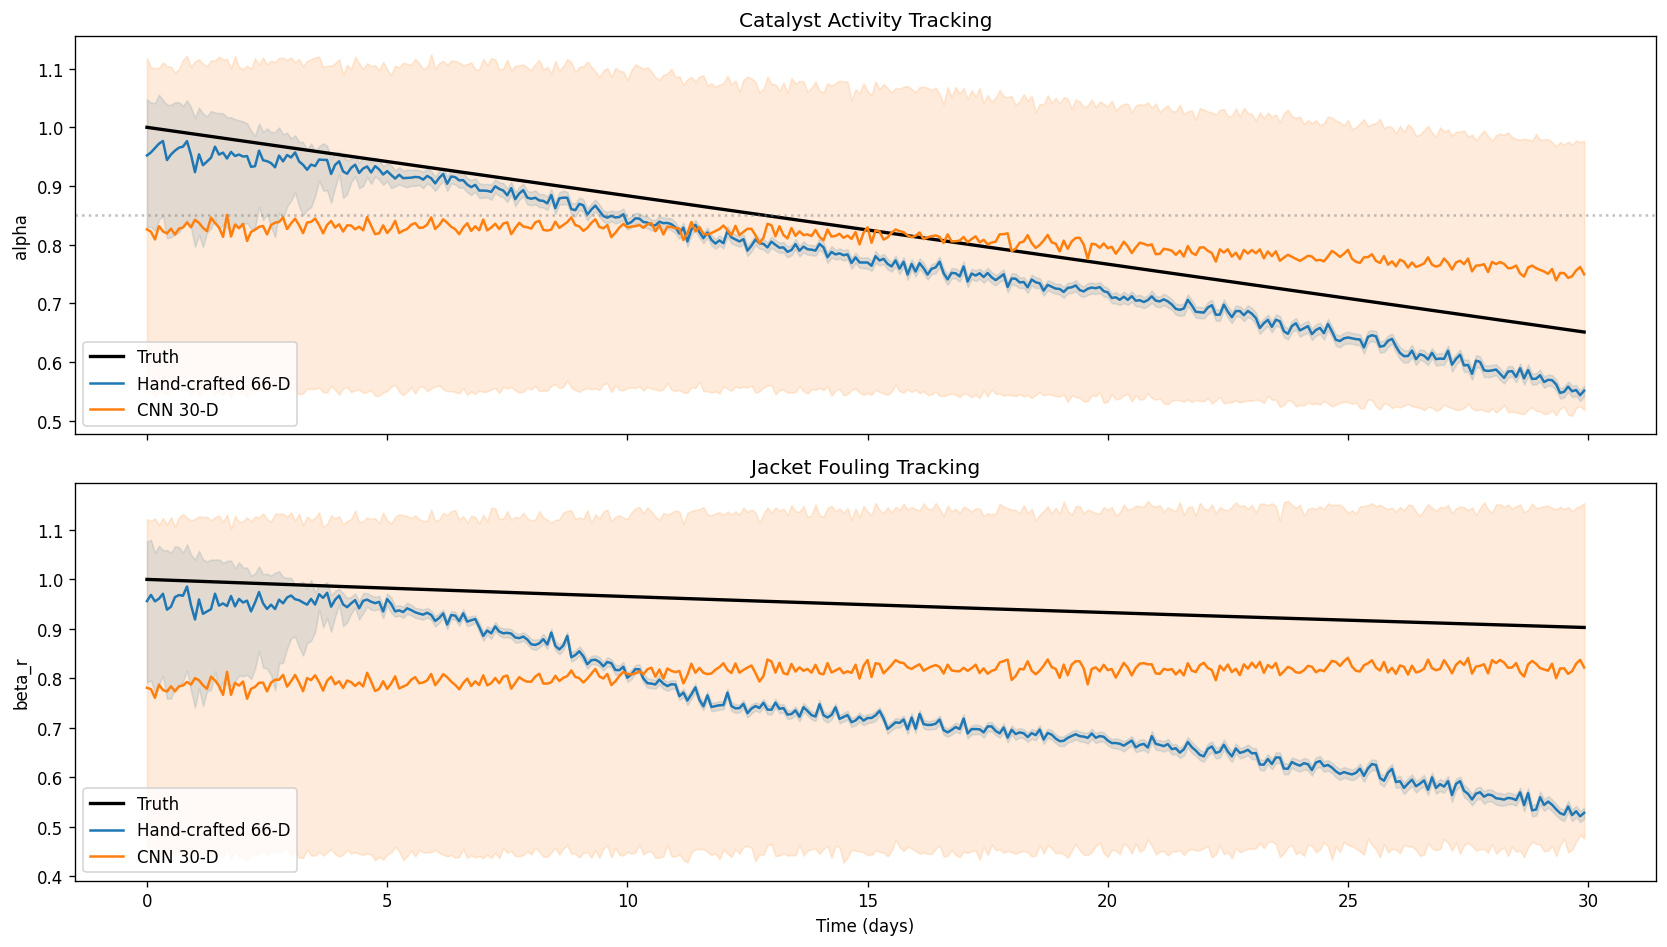

Saved 32_cnn_30day_tracking.png


In [19]:
# Tracking plot and MAE comparison
cnn_alpha_mean  = cnn_track[:, :, 0].mean(axis=1)
hc_alpha_mean   = hc_track[:, :, 0].mean(axis=1)
cnn_betar_mean  = cnn_track[:, :, 1].mean(axis=1)
hc_betar_mean   = hc_track[:, :, 1].mean(axis=1)

# 90% CI bands
cnn_alpha_lo = np.percentile(cnn_track[:, :, 0], 5, axis=1)
cnn_alpha_hi = np.percentile(cnn_track[:, :, 0], 95, axis=1)
hc_alpha_lo  = np.percentile(hc_track[:, :, 0], 5, axis=1)
hc_alpha_hi  = np.percentile(hc_track[:, :, 0], 95, axis=1)
cnn_betar_lo = np.percentile(cnn_track[:, :, 1], 5, axis=1)
cnn_betar_hi = np.percentile(cnn_track[:, :, 1], 95, axis=1)
hc_betar_lo  = np.percentile(hc_track[:, :, 1], 5, axis=1)
hc_betar_hi  = np.percentile(hc_track[:, :, 1], 95, axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Alpha tracking
ax = axes[0]
ax.plot(t_days, alpha_30, 'k-', lw=2, label='Truth')
ax.plot(t_days, hc_alpha_mean, color=OI[0], lw=1.5, label='Hand-crafted 66-D')
ax.fill_between(t_days, hc_alpha_lo, hc_alpha_hi, color=OI[0], alpha=0.15)
ax.plot(t_days, cnn_alpha_mean, color=OI[1], lw=1.5, label='CNN 30-D')
ax.fill_between(t_days, cnn_alpha_lo, cnn_alpha_hi, color=OI[1], alpha=0.15)
ax.set_ylabel('alpha')
ax.set_title('Catalyst Activity Tracking')
ax.legend(loc='lower left')
ax.axhline(0.85, ls=':', color='gray', alpha=0.5)

# Beta_r tracking
ax = axes[1]
ax.plot(t_days, beta_r_30, 'k-', lw=2, label='Truth')
ax.plot(t_days, hc_betar_mean, color=OI[0], lw=1.5, label='Hand-crafted 66-D')
ax.fill_between(t_days, hc_betar_lo, hc_betar_hi, color=OI[0], alpha=0.15)
ax.plot(t_days, cnn_betar_mean, color=OI[1], lw=1.5, label='CNN 30-D')
ax.fill_between(t_days, cnn_betar_lo, cnn_betar_hi, color=OI[1], alpha=0.15)
ax.set_ylabel('beta_r')
ax.set_xlabel('Time (days)')
ax.set_title('Jacket Fouling Tracking')
ax.legend(loc='lower left')

plt.tight_layout()
plt.savefig(FIGURES / '32_cnn_30day_tracking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 32_cnn_30day_tracking.png')

In [20]:
# MAE comparison
hc_mae_alpha  = np.mean(np.abs(hc_alpha_mean - alpha_30))
cnn_mae_alpha = np.mean(np.abs(cnn_alpha_mean - alpha_30))
hc_mae_betar  = np.mean(np.abs(hc_betar_mean - beta_r_30))
cnn_mae_betar = np.mean(np.abs(cnn_betar_mean - beta_r_30))

# EKF reference from nb27
ekf_mae_alpha = 0.002
ekf_mae_betar = 0.004

print(f"{'Method':<20} {'alpha MAE':>12} {'beta_r MAE':>12}")
print('-' * 46)
print(f"{'Hand-crafted 66-D':<20} {hc_mae_alpha:12.4f} {hc_mae_betar:12.4f}")
print(f"{'CNN 30-D':<20} {cnn_mae_alpha:12.4f} {cnn_mae_betar:12.4f}")
print(f"{'EKF (nb27 ref)':<20} {ekf_mae_alpha:12.4f} {ekf_mae_betar:12.4f}")
print()
if hc_mae_alpha > 0:
    print(f'CNN alpha MAE improvement: {(1 - cnn_mae_alpha/hc_mae_alpha)*100:.1f}%')
if hc_mae_betar > 0:
    print(f'CNN beta_r MAE improvement: {(1 - cnn_mae_betar/hc_mae_betar)*100:.1f}%')

Method                  alpha MAE   beta_r MAE
----------------------------------------------
Hand-crafted 66-D          0.0482       0.1980
CNN 30-D                   0.0671       0.1393
EKF (nb27 ref)             0.0020       0.0040

CNN alpha MAE improvement: -39.4%
CNN beta_r MAE improvement: 29.6%


---
## §8 — Summary and conclusions

In [21]:
print('='*70)
print('CNN EMBEDDING STUDY — CONSOLIDATED RESULTS')
print('='*70)

# SBC
n_pass = sum(1 for r in per_seed_results if r['min_ks_pvalue'] > 0.05)
best_ks = max(r['min_ks_pvalue'] for r in per_seed_results)
print(f'\n1. SBC CALIBRATION')
print(f'   Seeds passing SBC: {n_pass}/{N_SEEDS}')
print(f'   Best min(KS p): {best_ks:.4f}')

# Artifact resolution
print(f'\n2. ARTIFACT RESOLUTION')
for sc_name, info in ARTIFACT_SCENARIOS.items():
    sl = scenario_slices[sc_name]
    i1, i2 = info['pidx']
    cnn_pooled = cnn_samples[sl].reshape(-1, 5)
    hc_pooled  = hc_samples[sl].reshape(-1, 5)
    hc_corr  = np.corrcoef(hc_pooled[:, i1], hc_pooled[:, i2])[0, 1]
    cnn_corr = np.corrcoef(cnn_pooled[:, i1], cnn_pooled[:, i2])[0, 1]
    p1, p2 = info['params']
    print(f'   {sc_name}: corr({p1},{p2}) HC={hc_corr:+.3f} -> CNN={cnn_corr:+.3f}')

# Classification
print(f'\n3. FAULT CLASSIFICATION')
print(f'   Macro-F1:  HC={hc_f1:.3f} -> CNN={cnn_f1:.3f}')
print(f'   Accuracy:  HC={hc_acc:.3f} -> CNN={cnn_acc:.3f}')
print(f'   Feed F1:   HC={hc_f1c["feed"]:.3f} -> CNN={cnn_f1c["feed"]:.3f}')

# 30-day tracking
print(f'\n4. 30-DAY PROGRESSIVE TRACKING')
print(f'   alpha MAE:  HC={hc_mae_alpha:.4f} -> CNN={cnn_mae_alpha:.4f} (EKF ref: {ekf_mae_alpha})')
print(f'   beta_r MAE: HC={hc_mae_betar:.4f} -> CNN={cnn_mae_betar:.4f} (EKF ref: {ekf_mae_betar})')

print(f'\n' + '='*70)

CNN EMBEDDING STUDY — CONSOLIDATED RESULTS

1. SBC CALIBRATION
   Seeds passing SBC: 1/8
   Best min(KS p): 0.1366

2. ARTIFACT RESOLUTION
   W11_reactor_combined: corr(alpha,beta_r) HC=+0.994 -> CNN=+0.993
   W12_snowball_compound: corr(alpha,eta_col) HC=+0.011 -> CNN=+0.010
   W10_feed_impurity: corr(alpha,z_A0_eff) HC=+0.995 -> CNN=-0.004
   W13_cat_feed: corr(alpha,z_A0_eff) HC=+0.993 -> CNN=-0.003

3. FAULT CLASSIFICATION
   Macro-F1:  HC=0.679 -> CNN=0.270
   Accuracy:  HC=0.869 -> CNN=0.619
   Feed F1:   HC=0.000 -> CNN=0.000

4. 30-DAY PROGRESSIVE TRACKING
   alpha MAE:  HC=0.0482 -> CNN=0.0671 (EKF ref: 0.002)
   beta_r MAE: HC=0.1980 -> CNN=0.1393 (EKF ref: 0.004)

